# Multi-layer artificial neural networks

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

## Step 0: Get the MNIST dataset

This is a publicly-available handwritten digit dataset [link](https://web.archive.org/web/20200430193701/http://yann.lecun.com/exdb/mnist/)

In [2]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.values
y = y.astype(int).values

print(X.shape)
print(y.shape)

(70000, 784)
(70000,)


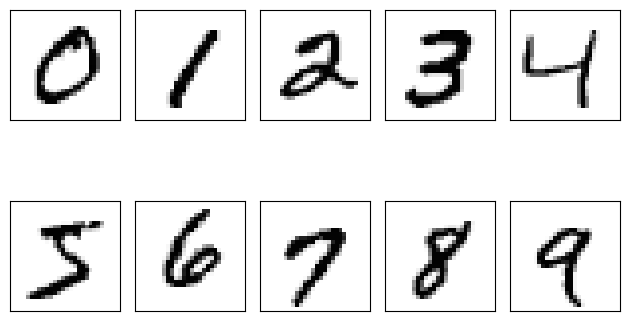

In [3]:
fig, ax = plt.subplots(2, 5, sharex=True, sharey=True)
ax = ax.flatten()
for ii in range(10):
    example_img = X[y == ii][0].reshape([28, 28])
    ax[ii].imshow(example_img, cmap='Greys')
    ax[ii].set(xticks=[], yticks=[])
plt.tight_layout()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

def normalize(X):
    return 2. * X / 255. - 1.

label_encoder = OneHotEncoder(sparse_output=False)
y_enc = label_encoder.fit_transform(y[:, None])

X_train, X_test, y_train, y_test = train_test_split(normalize(X), y_enc, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"The training set has size {X_train.shape}, {y_train.shape}")
print(f"The validation set has size {X_val.shape}, {y_val.shape}")
print(f"The testing set has size {X_test.shape}, {y_test.shape}")

The training set has size (44800, 784), (44800, 10)
The validation set has size (11200, 784), (11200, 10)
The testing set has size (14000, 784), (14000, 10)


In [5]:
from sklearn.linear_model import LogisticRegression

def mse_loss(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def accuracy(y_true, y_pred):
    y_label = np.argmax(y_true, axis=1)
    pred_label = np.argmax(y_pred, axis=1)
    return np.mean(y_label == pred_label)

lr_model = LogisticRegression()
lr_model.fit(X_train, label_encoder.inverse_transform(y_train)[:, 0])

y_train_pred = lr_model.predict_proba(X_train)
train_mse = mse_loss(y_train, y_train_pred)
train_acc = accuracy(y_train, y_train_pred)
print(f"Train MSE = {train_mse:.3f}\tTrain Accuracy = {train_acc:.3f}")

y_test_pred = lr_model.predict_proba(X_test)
test_mse = mse_loss(y_test, y_test_pred)
test_acc = accuracy(y_test, y_test_pred)
print(f"Test MSE = {test_mse:.3f}\tTest Accuracy = {test_acc:.3f}")

Train MSE = 0.010	Train Accuracy = 0.932
Test MSE = 0.012	Test Accuracy = 0.916


/Users/jcolen/miniconda3/envs/clinical_informatics_env/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Step 1 - Define a multi-layer perceptron

In [6]:
import numpy as np

def sigmoid(z):
    return 1. / (1. + np.exp(-z))

class MLP:
    """Multi-layer perceptron with sigmoid activations"""
    def __init__(self, num_inputs, num_hidden, num_outputs, random_seed=42):
        self.num_inputs = num_inputs
        self.num_hidden = num_hidden
        self.num_outputs = num_outputs
        self.random_seed = random_seed

        self._initialize_weights()

    def _initialize_weights(self):
        self.rng = np.random.default_rng(seed=self.random_seed)

        self.w_hidden = self.rng.normal(loc=0, scale=0.1, size=(self.num_hidden, self.num_inputs))
        self.b_hidden = np.zeros(self.num_hidden)

        self.w_output = self.rng.normal(loc=0, scale=0.1, size=(self.num_outputs, self.num_hidden))
        self.b_output = np.zeros(self.num_outputs)

    def forward(self, x):
        """ Feed the input data x through each network layer """
        # Apply hidden layer function
        z_hidden = np.dot(x, self.w_hidden.T) + self.b_hidden
        a_hidden = sigmoid(z_hidden)

        # Apply output layer function
        z_output = np.dot(a_hidden, self.w_output.T) + self.b_output
        a_output = sigmoid(z_output)

        return a_output, a_hidden

    def backward(self, x, y, a_output, a_hidden):
        """ Compute gradients with respect to each model parameter"""
        # Output layer gradients
        # We are going to assume MSE loss for simplicity
        d_loss__d_a_output = 2. / y.shape[0] * (a_output - y) # [B, num_outputs]
        d_a_output__d_z_output = a_output * (1. - a_output) # [B, num_outputs]
        d_loss__d_z_output = d_loss__d_a_output * d_a_output__d_z_output # [B, num_outputs]
        
        d_z_output__d_w_output = a_hidden # [B, num_hidden]
        d_z_output__d_b_output = 1.

        d_loss__d_w_output = np.einsum('Bi,Bj->ij', d_loss__d_z_output, d_z_output__d_w_output) # [num_outputs, num_hidden]
        d_loss__d_b_output = d_loss__d_z_output.sum(axis=0) * d_z_output__d_b_output # [num_outputs]

        # Hidden layer gradients
        d_z_output__d_a_hidden = self.w_output # [num_outputs, num_hidden]
        d_a_hidden__d_z_hidden = a_hidden * (1. - a_hidden) # [B, num_hidden]

        d_loss__d_z_hidden = np.einsum('Bi,ij->Bj', d_loss__d_z_output, d_z_output__d_a_hidden) * d_a_hidden__d_z_hidden # [B, num_hidden]

        d_z_hidden__d_w_hidden = x # [B, num_inputs]
        d_z_hidden__d_b_hidden = 1.

        d_loss__d_w_hidden = np.einsum('Bj,Bk->jk', d_loss__d_z_hidden, d_z_hidden__d_w_hidden) # [num_hidden, num_inputs]
        d_loss__d_b_hidden = d_loss__d_z_hidden.sum(axis=0) * d_z_hidden__d_b_hidden #[num_hidden]

        return d_loss__d_w_output, d_loss__d_b_output, \
               d_loss__d_w_hidden, d_loss__d_b_hidden

In [7]:
model = MLP(num_inputs=X_train.shape[1], num_hidden=64, num_outputs=y_train.shape[1])

## Training preliminaries: batch loader, loss function, tracking statistics

In [8]:
def batch_loader(X, y, batch_size=32):
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    for start in range(0, indices.shape[0] - batch_size + 1, batch_size):
        batch_idx = indices[start:start+batch_size]
        yield X[batch_idx], y[batch_idx]

loader = batch_loader(X_train, y_train, batch_size=32)
Xb, yb = next(loader)
print(Xb.shape, yb.shape)

(32, 784) (32, 10)


In [9]:
def mse_loss(y_true, y_pred):
    return np.mean(np.power(y_true - y_pred, 2))

def accuracy(y_true, y_pred):
    y_label = np.argmax(y_true, axis=1)
    pred_label = np.argmax(y_pred, axis=1)
    return np.mean(y_label == pred_label)

y_pred, _ = model.forward(X_val)
mse = mse_loss(y_val, y_pred)
acc = accuracy(y_val, y_pred)

print(f'Initial Val MSE: {mse:.3f}, Val Accuracy: {acc:.3f}')

Initial Val MSE: 0.252, Val Accuracy: 0.091


## Training loop

In [19]:
def train(model, X_train, y_train, X_val, y_val, num_epochs=10, batch_size=128, lr=0.3):
    train_mse, train_acc, val_mse, val_acc = [], [], [], []

    for ii in range(num_epochs):
        loader = batch_loader(X_train, y_train, batch_size=batch_size)
        for X_batch, y_batch in loader:
            a_output, a_hidden = model.forward(X_batch)
            d_loss__d_w_output, d_loss__d_b_output, d_loss__d_w_hidden, d_loss__d_b_hidden = \
                model.backward(X_batch, y_batch, a_output, a_hidden)

            model.w_output -= lr * d_loss__d_w_output
            model.b_output -= lr * d_loss__d_b_output
            model.w_hidden -= lr * d_loss__d_w_hidden
            model.b_hidden -= lr * d_loss__d_b_hidden

        y_train_pred, _ = model.forward(X_train)
        train_mse.append(mse_loss(y_train, y_train_pred))
        train_acc.append(accuracy(y_train, y_train_pred))

        y_val_pred, _ = model.forward(X_val)
        val_mse.append(mse_loss(y_val, y_val_pred))
        val_acc.append(accuracy(y_val, y_val_pred))

        print(f"Epoch {ii+1:03d} / {num_epochs:03d} | " \
              f"Train MSE = {train_mse[-1]:.3f}, Train Acc = {train_acc[-1]:.3f} | " \
              f"Val MSE = {val_mse[-1]:.3f}, Val Acc = {val_acc[-1]:.3f}")

        lr *= 0.99

    return train_mse, train_acc, val_mse, val_acc

In [20]:
model = MLP(num_inputs=X_train.shape[1], num_hidden=64, num_outputs=y_train.shape[1])
train_mse, train_acc, val_mse, val_acc = train(model, X_train, y_train, X_val, y_val, num_epochs=40)

Epoch 001 / 040 | Train MSE = 0.032, Train Acc = 0.851 | Val MSE = 0.032, Val Acc = 0.843
Epoch 002 / 040 | Train MSE = 0.021, Train Acc = 0.893 | Val MSE = 0.022, Val Acc = 0.889
Epoch 003 / 040 | Train MSE = 0.018, Train Acc = 0.905 | Val MSE = 0.018, Val Acc = 0.900
Epoch 004 / 040 | Train MSE = 0.016, Train Acc = 0.915 | Val MSE = 0.016, Val Acc = 0.907
Epoch 005 / 040 | Train MSE = 0.014, Train Acc = 0.920 | Val MSE = 0.015, Val Acc = 0.913
Epoch 006 / 040 | Train MSE = 0.014, Train Acc = 0.924 | Val MSE = 0.014, Val Acc = 0.916
Epoch 007 / 040 | Train MSE = 0.013, Train Acc = 0.926 | Val MSE = 0.014, Val Acc = 0.919
Epoch 008 / 040 | Train MSE = 0.012, Train Acc = 0.931 | Val MSE = 0.013, Val Acc = 0.923
Epoch 009 / 040 | Train MSE = 0.012, Train Acc = 0.934 | Val MSE = 0.013, Val Acc = 0.926
Epoch 010 / 040 | Train MSE = 0.011, Train Acc = 0.937 | Val MSE = 0.012, Val Acc = 0.928
Epoch 011 / 040 | Train MSE = 0.011, Train Acc = 0.938 | Val MSE = 0.012, Val Acc = 0.928
Epoch 012 

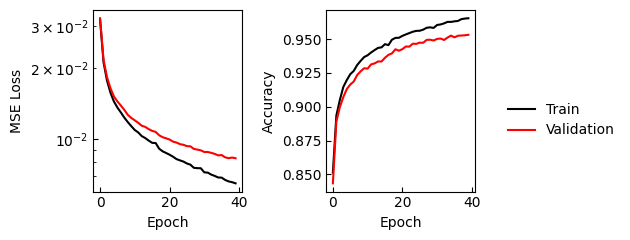

In [21]:
fig, ax = plt.subplots(1, 2, sharex=True, figsize=(5, 2.5))

ax[0].plot(train_mse, color='black', label='Train')
ax[0].plot(val_mse, color='red', label='Validation')
ax[0].set(xlabel='Epoch', ylabel='MSE Loss', yscale='log')

ax[1].plot(train_acc, color='black', label='Train')
ax[1].plot(val_acc, color='red', label='Validation')
ax[1].set(xlabel='Epoch', ylabel='Accuracy')

fig.legend(*ax[1].get_legend_handles_labels(), 
           loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

plt.tight_layout()

In [22]:
y_test_pred, _ = model.forward(X_test)
test_mse = mse_loss(y_test, y_test_pred)
test_acc = accuracy(y_test, y_test_pred)
print(f"Test MSE = {test_mse:.3f}\tTest Accuracy = {test_acc:.3f}")

Test MSE = 0.008	Test Accuracy = 0.952


## Examine failed cases

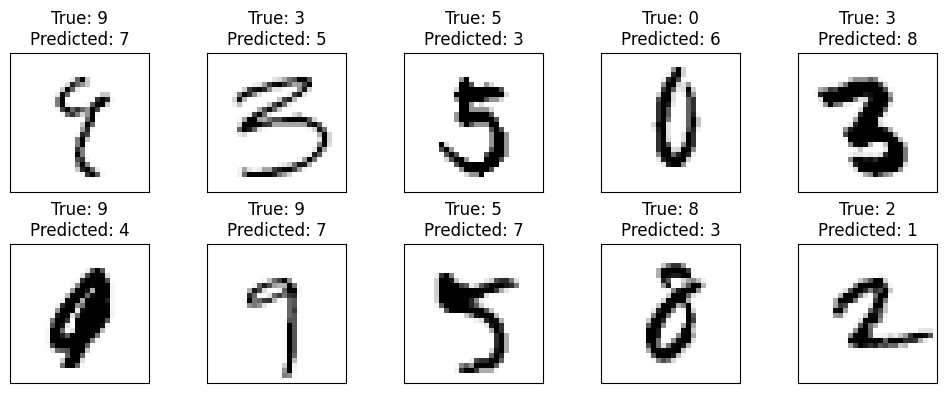

In [23]:
wrong = np.where(np.argmax(y_test_pred, axis=1) != np.argmax(y_test, axis=1))[0]

fig, ax = plt.subplots(2, 5, figsize=(10, 4), sharex=True, sharey=True)
ax = ax.flatten()

for ii in range(10):
    img = X_test[wrong[ii], :].reshape([28, 28])
    true_label = np.argmax(y_test[wrong[ii]])
    pred_label = np.argmax(y_test_pred[wrong[ii]])

    ax[ii].imshow(img, cmap='Greys')
    ax[ii].set(xticks=[], yticks=[], title=f"True: {true_label}\nPredicted: {pred_label}")

plt.tight_layout()

## Examine learned representations

Each hidden layer neuron is sensitive to a particular pixel configuration. We can visualize this to get an understanding for the input representations that the model produces.

In [24]:
model.w_hidden.shape

(64, 784)

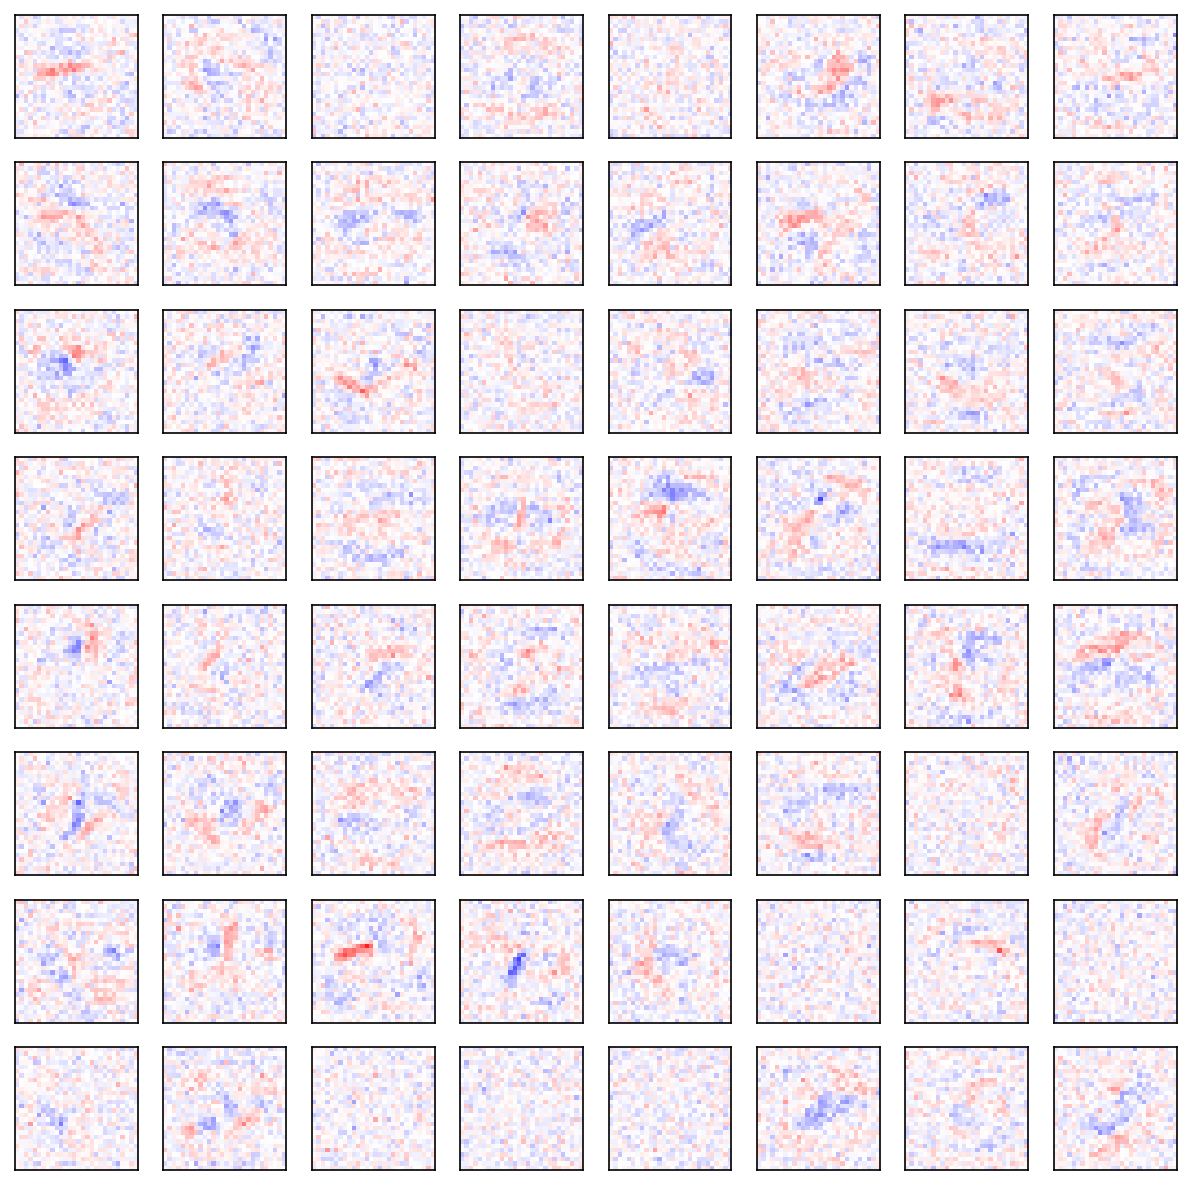

In [25]:
fig, axes = plt.subplots(8, 8, figsize=(10, 10), dpi=150)

for weights, ax in zip(model.w_hidden, axes.ravel()):
    w_img = weights.reshape([28,28])
    ax.imshow(w_img, cmap='bwr', vmin=-1, vmax=1)
    ax.set(xticks=[], yticks=[])
